**Installing Dependencies**

In [8]:
!pip install -qU langchain langchain-huggingface langchain-qdrant langchain-groq langchain-text-splitters
!pip install -q sentence-transformers qdrant-client

In [9]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

LangChain provides an integration with the Groq API, so once our API Key is set we can inference the Groq LLMs via langchain.

You can access all the models mentioned here: [Groq/Models](https://console.groq.com/docs/models)

You can learn more about LangChain Chat models here: [LangChain Models](https://docs.langchain.com/oss/python/langchain/models)



In [10]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
)

### **Basic LLM calling**
This is the first step to get familiar with the LangChain ecosystem. We'll do inferencing with Groq API via the LangChain Chat wrapper.

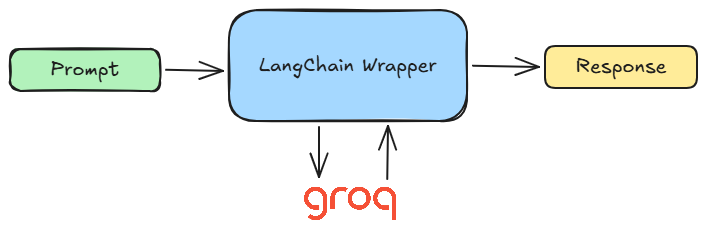

In [11]:
resp = llm.invoke("What is the capital of India?")
print(resp.content)

The capital of India is **New Delhi**.


### **LLM Call with System Prompt**

In LangChain, we can represnt the input and output from various entitis as messages, which act as context for the models.

Message types
 - **System message** - Tells the model how to behave and provide context for interactions
 - **Human message** - Represents user input and interactions with the model
 - **AI message** - Responses generated by the model, including text content, tool calls, and metadata
 - **Tool message** - Represents the outputs of tool calls


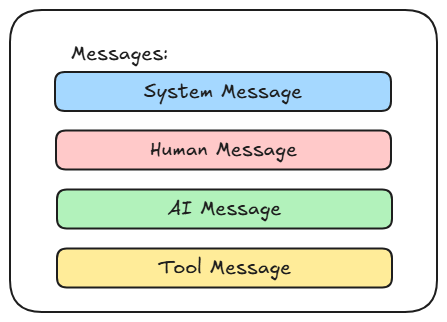

In [12]:
response = llm.invoke(
    [
      (
          "system",
          "You are a helpful assistant that reviews python code and suggests improvement",
      ),
      ("human", """
  def process_data(data_list):
    for item in data_list:
        if "@" in item:
            print("Email:", item)
        else:
            try:
                num = int(item)
                print("Number:", num * 2)
            except:
                print("Other:", item)

      """),
    ]
)

print(response.content)

**Code review & suggestions**

Below is the original snippet (with the indentation problem highlighted):

```python
def process_data(data_list):
    for item in data_list:
        if "@" in item:
            print("Email:", item)
        else:
            try:
                num = int(item)
                print("Number:", num * 2)
            except:
                print("Other:", item)
```

### 1️⃣ What’s good
* The logic is clear:  
  * Detect an e‑mail address (contains “@”).  
  * Try to treat the value as an integer and double it.  
  * Fallback to a generic “Other” case.
* The function is small and easy to read.

---

## 2️⃣ Areas for improvement

| Issue | Why it matters | How to fix it |
|-------|----------------|---------------|
| **Indentation / formatting** | Inconsistent indentation can cause a `IndentationError` and makes the code harder to read. | Use 4 spaces per level (PEP 8). |
| **Bare `except:`** | Catches *all* exceptions, including `KeyboardInterrupt` and `Syste

# **Building RAG Pipeline in LangChain**

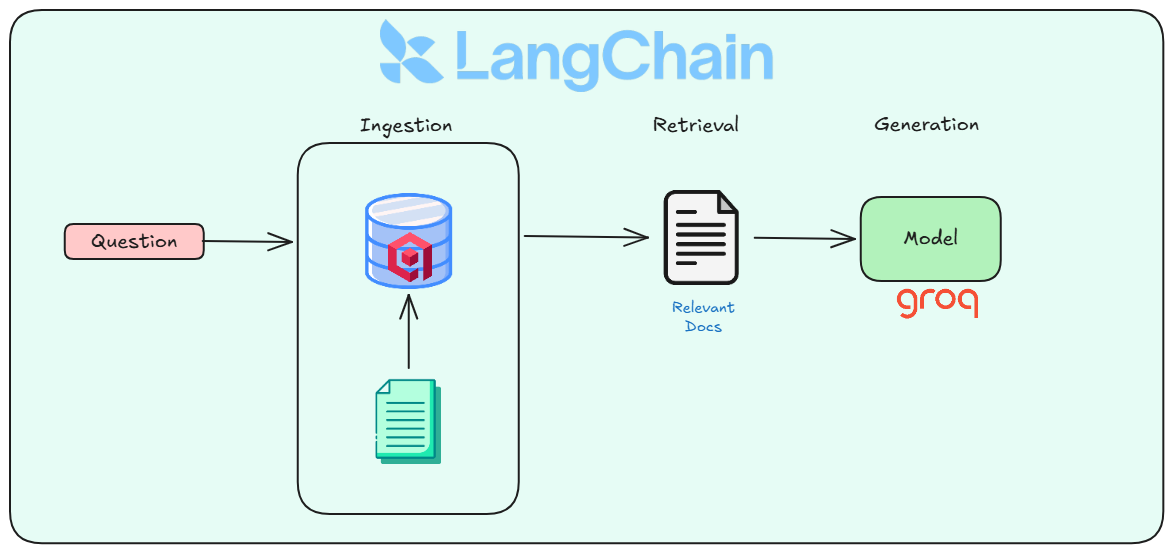

### **Document Loading & Chunking**
It's an essential preprocessing step where we break down large documents into smaller, manageable, and semantically meaningful text segments.

It optimizes RAG by ensuring retrieval accuracy, fitting content into LLM context windows, and reducing retrieval time.

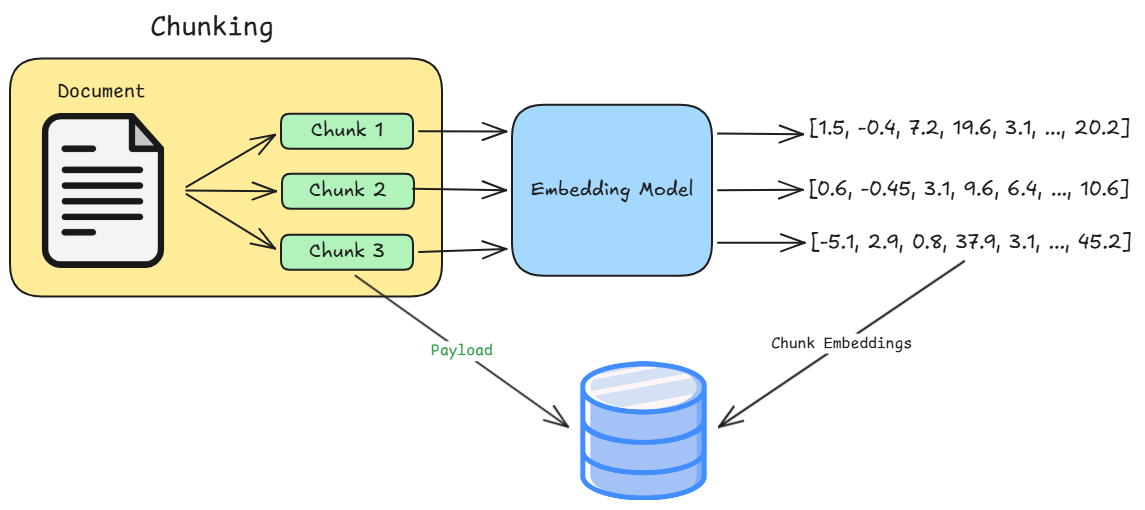





In [13]:
import requests
from langchain_core.documents import Document

WEB_URL = "https://raw.githubusercontent.com/tnahddisttud/sample-doc/refs/heads/main/atliqai_hr_policies.txt"

response = requests.get(WEB_URL)
response.raise_for_status()

docs = [Document(page_content=response.text, metadata={"source": WEB_URL})]
print(docs)

[Document(metadata={'source': 'https://raw.githubusercontent.com/tnahddisttud/sample-doc/refs/heads/main/atliqai_hr_policies.txt'}, page_content='# AtliqAI HR Policies\n\nAtliqAI is committed to building a transparent, inclusive, and high-performance workplace. This document outlines the policies and guidelines that govern employment, conduct, compensation, and well-being at AtliqAI. All employees are expected to read, understand, and adhere to these policies from their first day of joining.\n\n---\n\n## Employment & Onboarding\n\n### Offer and Joining Formalities\n\nUpon acceptance of an offer letter, candidates must complete the joining formalities within the stipulated date mentioned in the offer. The HR team will share a pre-joining checklist that includes submission of educational certificates, identity proof, address proof, previous employment documents, and a recent photograph. Failure to submit required documents within 7 working days of joining may result in withholding of the

In [14]:
from langchain_text_splitters import CharacterTextSplitter

text_splitter = CharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base", chunk_size=100, chunk_overlap=0
)
documents = text_splitter.split_documents(docs)
len(documents)

44

### **Embedding**

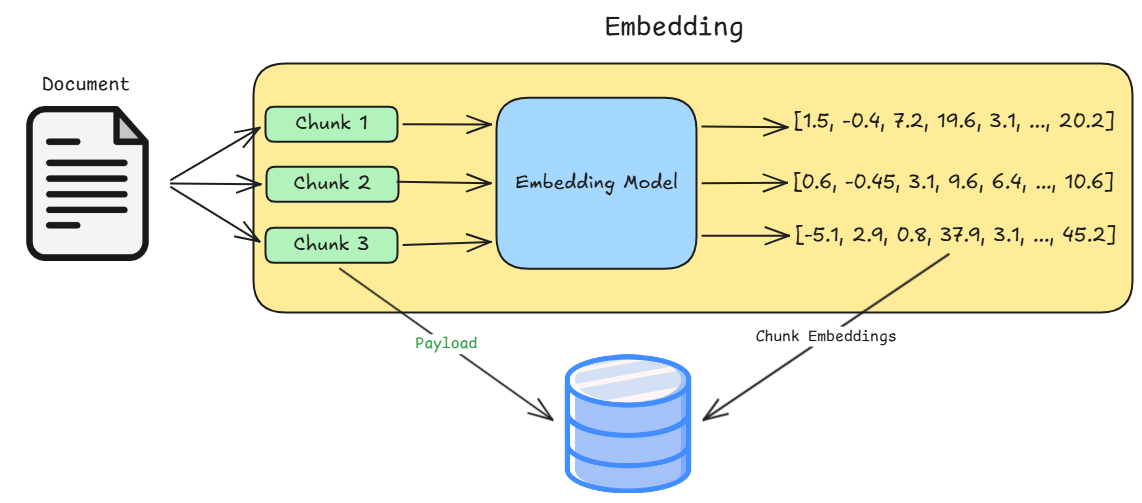

In [15]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import QdrantVectorStore

EMBED_MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"

embedder = HuggingFaceEmbeddings(model_name=EMBED_MODEL_ID)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### **Indexing**

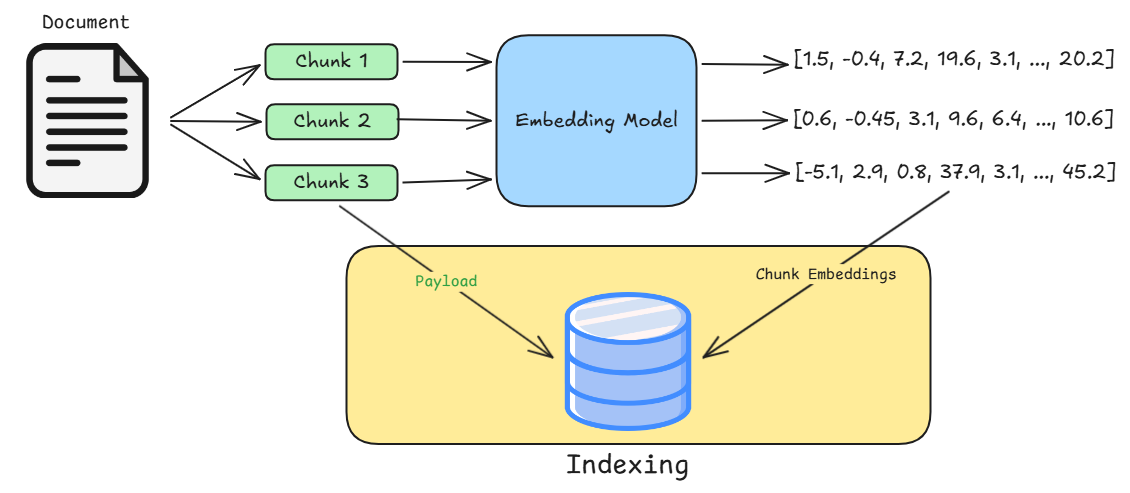

In [16]:
vectorstore = QdrantVectorStore.from_documents(
    documents=documents,
    embedding=embedder,
    path="/tmp/my_lang_vs",
    collection_name="hr_docs",
)

## **Retrieval**

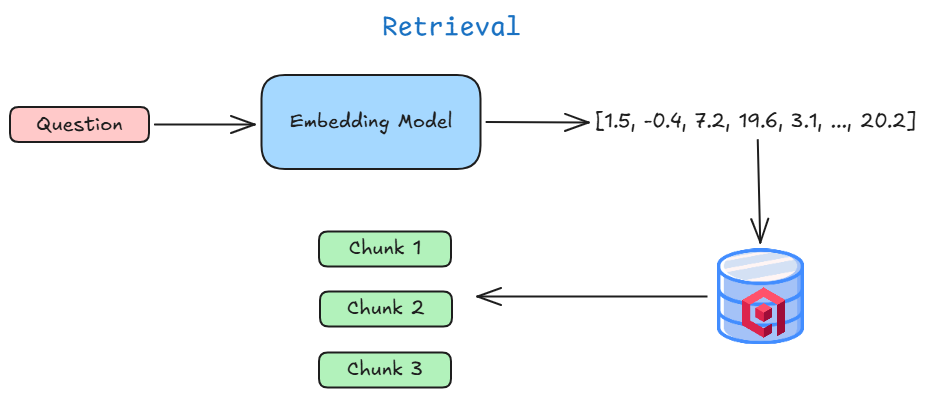

In [17]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

## **RAG Pipeline**

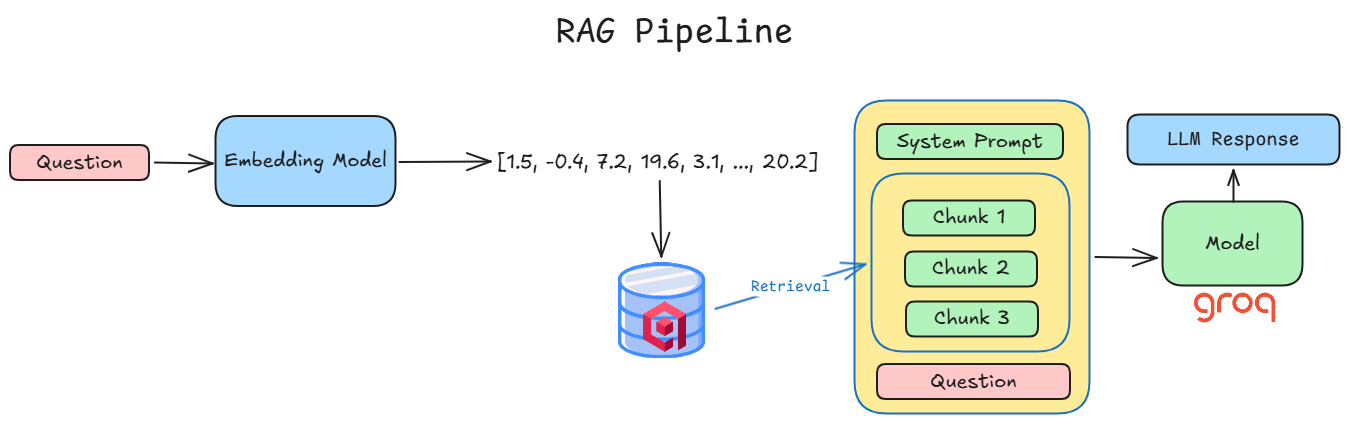

In [18]:
from langchain_core.prompts import ChatPromptTemplate

RAG_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "Answer using ONLY the context below. Cite section names. Say 'I don't know' if unsure."),
    ("human", "Context:\n{context}\n\nQuestion: {question}")
])

In [19]:
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
)

In [20]:
def format_docs(docs):
    parts = []
    for i, doc in enumerate(docs, 1):
        dl_meta  = doc.metadata.get("dl_meta", {})
        parts.append(f"[{i}]: \n{doc.page_content}")
    return "\n\n---\n\n".join(parts)

In [21]:
def rag(query: str) -> str:
    docs         = retriever.invoke(query)
    context      = format_docs(docs)
    prompt_value = RAG_PROMPT.invoke({"context": context, "question": query})
    response     = llm.invoke(prompt_value)
    return response.content

In [22]:
for q in [
        "How many casual leaves am I entitled to?",
        "What is the notice period for Band 4 employees?",
        "How long is the probation period?",
    ]:
        print(f"\nQ: {q}\nA: {rag(q)}\n")


Q: How many casual leaves am I entitled to?
A: You are entitled to **12 casual leaves per calendar year** (credited at 1 leave per month).【1】


Q: What is the notice period for Band 4 employees?
A: The notice period for Band 4 employees is **60 days**【1】.


Q: How long is the probation period?
A: The probation period is **6 months** from the date of joining. (See section [1])



In [23]:
docs_1 = retriever.invoke("How many casual leaves am I entitled to?")

In [24]:
context      = format_docs(docs_1)
print(context)

[1]: 
Every confirmed employee is entitled to 12 casual leaves per calendar year, credited at 1 leave per month. Casual leave can be availed for personal errands, minor illness, or unplanned absences. A maximum of 3 consecutive casual leaves can be taken at a time. Casual leaves cannot be carried forward to the next calendar year and lapse on December 31st.

### Sick Leave

---

[2]: 
Employees are entitled to 10 sick leaves per calendar year. Sick leave can be availed in case of illness, hospitalisation, or medical procedures. A medical certificate from a registered practitioner is mandatory for sick leave of more than 2 consecutive days. Unused sick leaves up to a maximum of 10 can be carried forward to the following year.

### Earned Leave

---

[3]: 
Employees who are unable to serve the full notice period may request a notice period buy-out, subject to management approval. The buy-out amount is calculated at the basic daily rate for each day of unserved notice. The amount will be 